In [14]:
import numpy as np
import pennylane as qml

In [ ]:
# queremos encontrar o estado |11> 

n_qubits = 3 

dev = qml.device("default.qubit", wires=n_qubits)


@qml.qnode(dev)
def grover_2qubits():
    #criar sobreposiçao nos qubits da base de dados
    for q in range(n_qubits - 1):
        qml.Hadamard(wires=q)
    #criar ancilla no estado |->
    qml.PauliX(wires=n_qubits-1)
    qml.Hadamard(wires=n_qubits-1)

    #oracle p/ encontrar |11> 
    qml.Toffoli(wires=[0,1,2])

    #difusor 
    for q in range(n_qubits - 1):
        qml.Hadamard(wires=q)
        qml.PauliX(wires=q)
    
    qml.CZ(wires=[0,1])

    for q in range(n_qubits - 1):
        qml.PauliX(wires=q)
        qml.Hadamard(wires=q)
    
    return qml.probs(wires=[0,1])
    






In [ ]:
qml.draw_mpl(grover_2qubits)()

In [ ]:
grover_2qubits()

In [25]:
# queremos encontrar o estado |11> 

n_qubits = 4

dev = qml.device("default.qubit", wires=n_qubits)


@qml.qnode(dev)
def grover_2qubits(iterations):
    #criar sobreposiçao nos qubits da base de dados
    for q in range(n_qubits - 1):
        qml.Hadamard(wires=q)
    #criar ancilla no estado |->
    qml.PauliX(wires=n_qubits-1)
    qml.Hadamard(wires=n_qubits-1)

    qml.Barrier()

    for j in range(iterations):
        #oracle p/ encontrar |1...1> 
        qml.ctrl(qml.PauliX , range(n_qubits-1))(n_qubits-1)
        
        for i in range(n_qubits - 1):
            qml.PauliX(wires=i)
        qml.ctrl(qml.PauliX, range(n_qubits-1))(n_qubits-1) 
        for i in range(n_qubits - 1):
            qml.PauliX(wires=i)
            
        qml.Barrier()   
        #difusor 
        for q in range(n_qubits - 1):
            qml.Hadamard(wires=q)
            qml.PauliX(wires=q)
        
        qml.ctrl(qml.PauliZ , range(n_qubits-2))(n_qubits-2) 

        for q in range(n_qubits - 1):
            qml.PauliX(wires=q)
            qml.Hadamard(wires=q)

        qml.Barrier()
    return qml.probs(wires=range(n_qubits-1))
    






(<Figure size 2800x500 with 1 Axes>, <Axes: >)

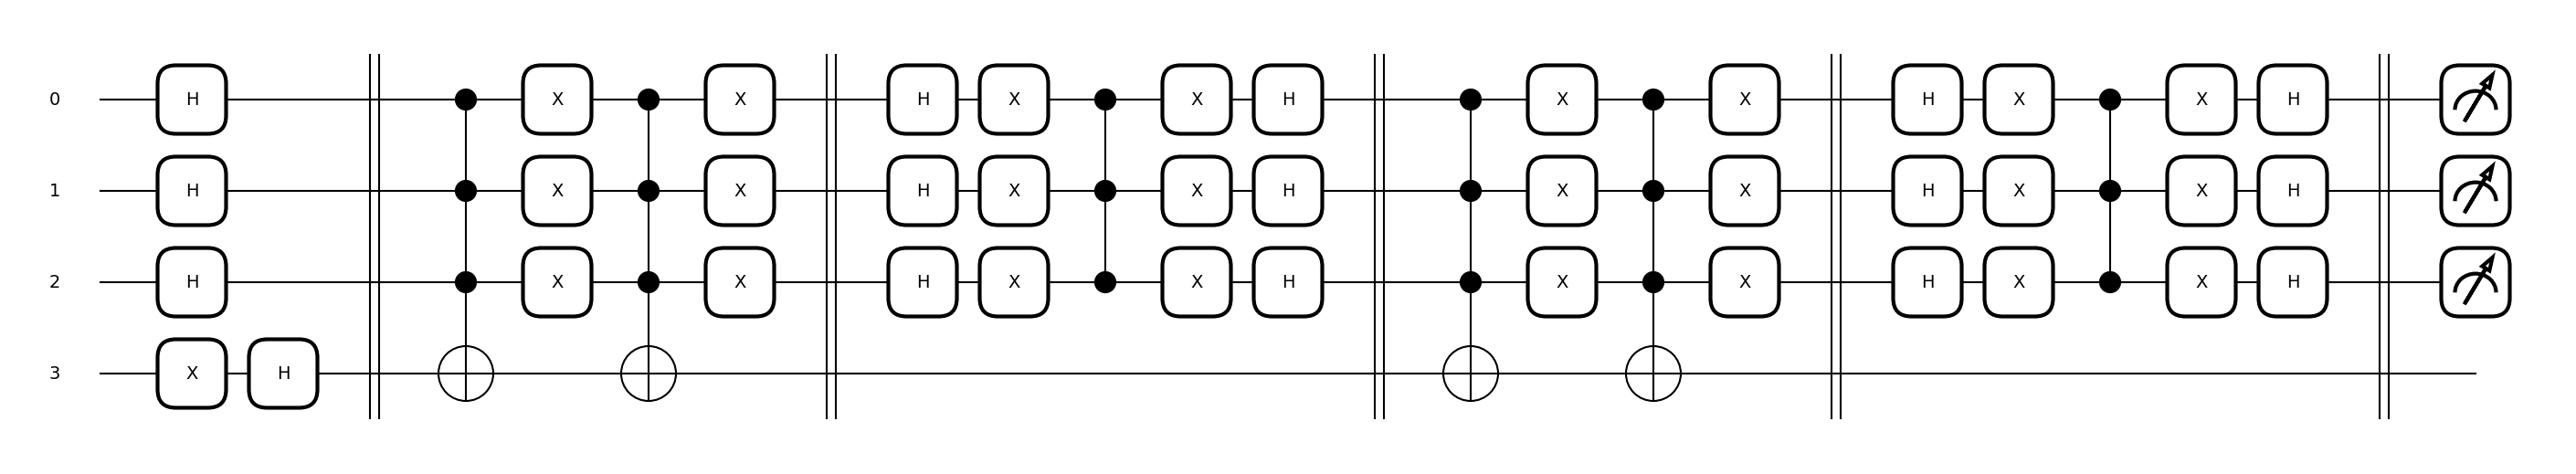

In [30]:

iterations = 2
qml.draw_mpl(grover_2qubits)(iterations)

In [31]:
p=grover_2qubits(iterations)
for i in range(2**(n_qubits-1)):
    print(f"|{i:0{n_qubits-1}b}>: {p[i]:.4f}")

|000>: 0.1250
|001>: 0.1250
|010>: 0.1250
|011>: 0.1250
|100>: 0.1250
|101>: 0.1250
|110>: 0.1250
|111>: 0.1250


In [35]:
N = 2**(n_qubits-1)
M=2
optimal_iterations = round((np.pi/(4*np.arcsin(np.sqrt(M/N)))) - 0.5)
print(f"Optimal number of iterations: {optimal_iterations}")

Optimal number of iterations: 1


In [36]:
# queremos encontrar o estado |11> 

n_qubits = 4

dev = qml.device("default.qubit", wires=n_qubits)


@qml.qnode(dev)
def grover_2qubits(iterations):
    #criar sobreposiçao nos qubits da base de dados
    for q in range(n_qubits - 1):
        qml.Hadamard(wires=q)
    #criar ancilla no estado |->
    qml.PauliX(wires=n_qubits-1)
    qml.Hadamard(wires=n_qubits-1)

    qml.Barrier()

    for j in range(iterations):
        #oracle p/ encontrar |1...1> 
        qml.ctrl(qml.PauliX , range(n_qubits-1))(n_qubits-1)
        
        for i in range(n_qubits - 1):
            qml.PauliX(wires=i)
        qml.ctrl(qml.PauliX, range(n_qubits-1))(n_qubits-1) 
        for i in range(n_qubits - 1):
            qml.PauliX(wires=i)
            
        qml.Barrier()   
        #difusor 
        for q in range(n_qubits - 1):
            qml.Hadamard(wires=q)
            qml.PauliX(wires=q)
        
        qml.ctrl(qml.PauliZ , range(n_qubits-2))(n_qubits-2) 

        for q in range(n_qubits - 1):
            qml.PauliX(wires=q)
            qml.Hadamard(wires=q)

        qml.Barrier()
    return qml.probs(wires=range(n_qubits-1))
    






In [38]:
N = 2**(n_qubits-1)
M=2
optimal_iterations = round((np.pi/(4*np.arcsin(np.sqrt(M/N)))) - 0.5)
print(f"Optimal number of iterations: {optimal_iterations}")


Optimal number of iterations: 1


(<Figure size 1700x500 with 1 Axes>, <Axes: >)

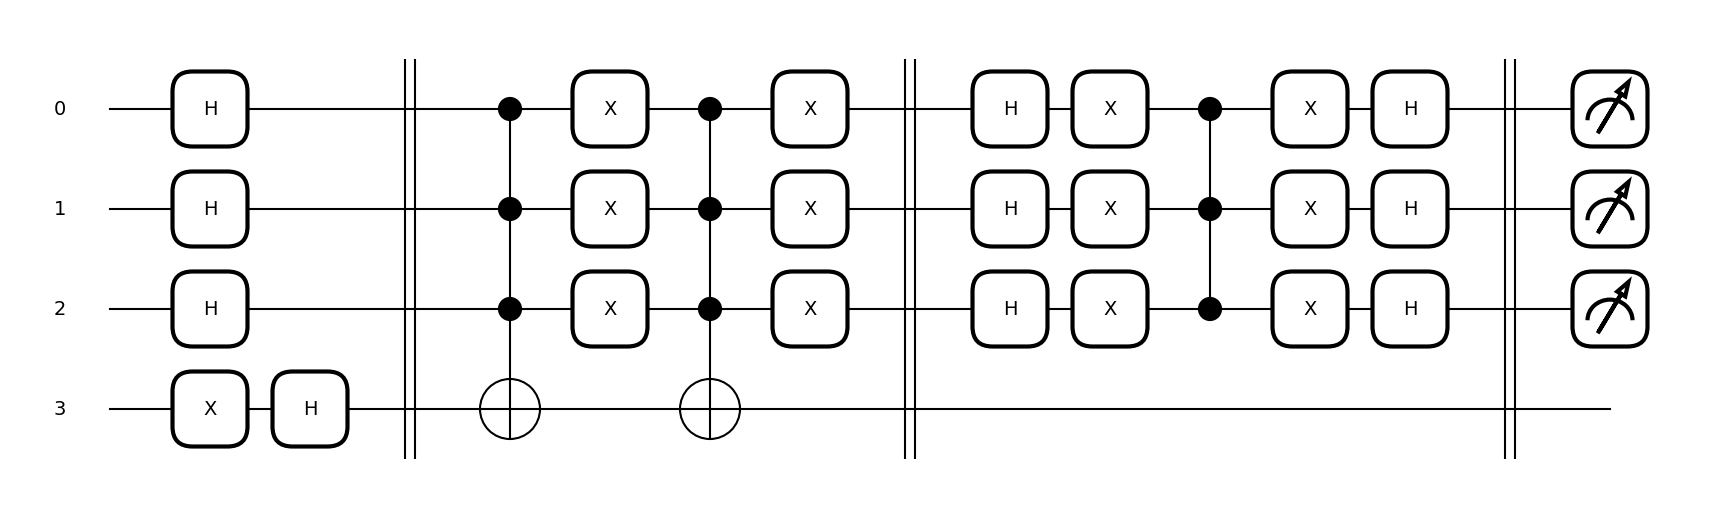

In [40]:
qml.draw_mpl(grover_2qubits)(optimal_iterations)

In [42]:
p=grover_2qubits(optimal_iterations)
for i in range(2**(n_qubits-1)):
    print(f"|{i:0{n_qubits-1}b}>: {p[i]:.4f}")

|000>: 0.5000
|001>: 0.0000
|010>: 0.0000
|011>: 0.0000
|100>: 0.0000
|101>: 0.0000
|110>: 0.0000
|111>: 0.5000
